<a href="https://colab.research.google.com/github/lightcode01-oss/IYB_INTERNSHIP/blob/main/Day_05_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DAY 05 — Exploratory Data Analysis

## YBI Foundation — Python, AI & Data Science Internship

### Objective

The objective of Day 05 is to perform Exploratory Data Analysis (EDA) on the
Student Performance dataset.

EDA helps in understanding distributions, relationships and patterns within
the data before machine learning.

### Today's Work

- Load the dataset independently.
- Review important numerical features.
- Analyze categorical features.
- Study the target variable.
- Compare student characteristics with performance.
- Analyze relationships between selected numerical variables.
- Examine correlations.
- Identify useful patterns for later feature preparation.

No machine learning model will be trained today.

In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load the UCI Student Performance dataset

student_performance = fetch_ucirepo(id=320)

X = student_performance.data.features
y = student_performance.data.targets

df = X.copy()
df["G3"] = y["G3"]

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (649, 31)


In [3]:
# Create project-defined performance categories

def performance_category(grade):
    if grade < 10:
        return "Low"
    elif grade < 15:
        return "Medium"
    else:
        return "High"

df["performance_category"] = df["G3"].apply(performance_category)

print(df["performance_category"].value_counts())

performance_category
Medium    418
High      131
Low       100
Name: count, dtype: int64


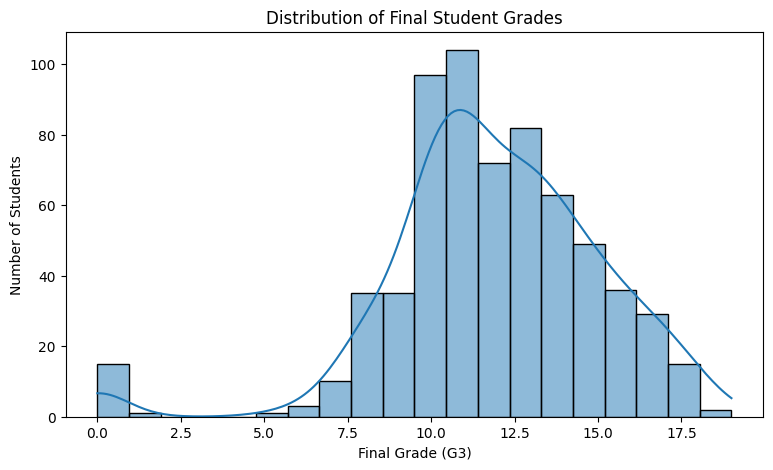

In [4]:
# Distribution of final grades

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="G3",
    bins=20,
    kde=True
)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

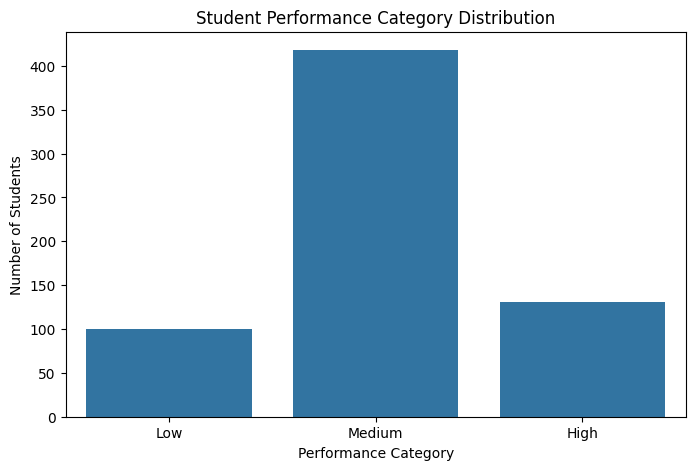

In [5]:
# Distribution of performance categories

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="performance_category",
    order=["Low", "Medium", "High"]
)

plt.title("Student Performance Category Distribution")
plt.xlabel("Performance Category")
plt.ylabel("Number of Students")

plt.show()

In [6]:
# Calculate performance category percentages

performance_distribution = (
    df["performance_category"]
    .value_counts(normalize=True)
    .reindex(["Low", "Medium", "High"])
    .mul(100)
    .round(2)
)

print(performance_distribution)

performance_category
Low       15.41
Medium    64.41
High      20.18
Name: proportion, dtype: float64


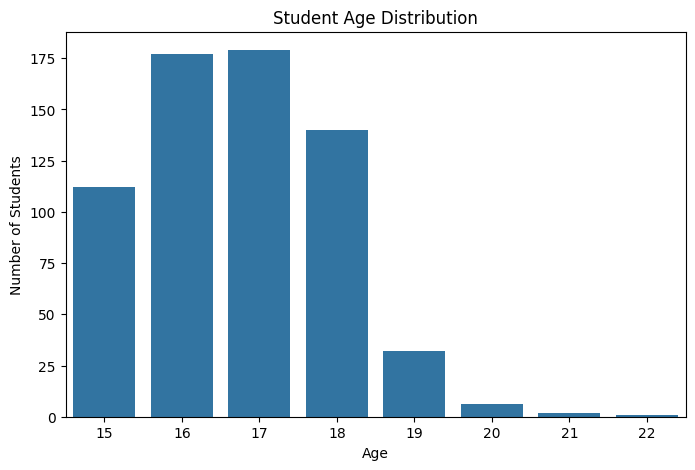

In [7]:
# Analyze student age distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="age"
)

plt.title("Student Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

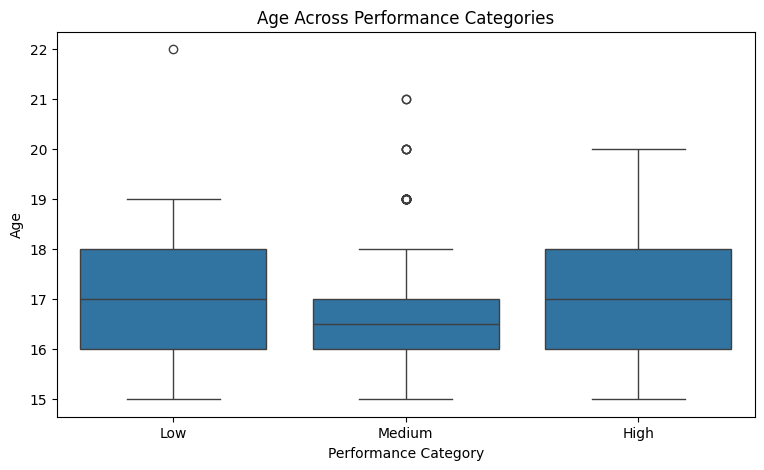

In [8]:
# Compare age across performance categories

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="performance_category",
    y="age",
    order=["Low", "Medium", "High"]
)

plt.title("Age Across Performance Categories")
plt.xlabel("Performance Category")
plt.ylabel("Age")

plt.show()

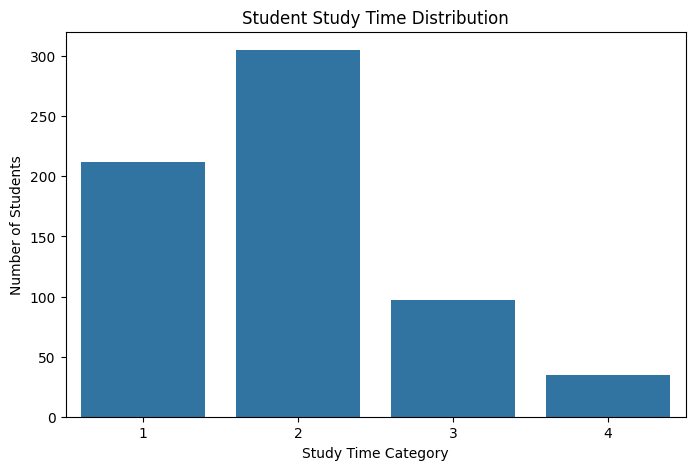

In [9]:
# Study time distribution

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="studytime"
)

plt.title("Student Study Time Distribution")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

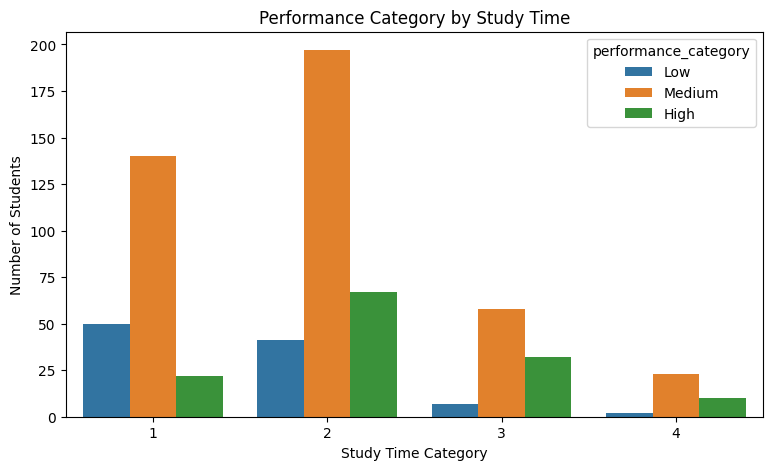

In [10]:
# Study time compared with performance

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="studytime",
    hue="performance_category",
    hue_order=["Low", "Medium", "High"]
)

plt.title("Performance Category by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()